# HiFi Phase 16 - Live 4-Arm Paper-Trading Report

**Status: EXPERIMENT IN PROGRESS - not for performance conclusions yet.**
Paper trading only. Not investment advice. Arms have different inception dates.

Four strategies, same 98-ticker universe, $100K each, one decision/day:

| Arm | Strategy | Type |
|---|---|---|
| **A** | parallel ensemble (champion) | LLM |
| **B** | full sequential (herding contrast) | LLM |
| **C** | equal-weight buy-and-hold | null control |
| **D** | riskbudget calm_exposure | deterministic quant |

Auto-generated from captured data. Four layers:
**1 Financial** (equity + full QuantStats tearsheet) · **2 Decisions** (Buy/Hold/Sell) ·
**3 AI-science** (herding/diversity, IC) · **4 AI-operations** (LangFuse: tokens/latency/cost).
Financial + QuantStats depth unlock once >=20 daily returns exist (early days are noise).

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
DATA = str(ROOT / "data")
try:
    from dotenv import load_dotenv; load_dotenv(ROOT / ".env")  # LangFuse creds for section 4
except Exception:
    pass

import pandas as pd, matplotlib.pyplot as plt
from hifi.analytics import live_report as lr
pd.set_option("display.width", 170); plt.rcParams["figure.figsize"] = (11, 5)
status = lr.experiment_status(DATA)
print("Repo:", ROOT)
print("Days of data:", status["days_of_data"], "| window:", status["first_date"], "->", status["last_date"])
print("Arms live:", status["arms_live"])
print("Live IC:", status["ic_status"])

Repo: /Users/alberto/Documents/projects/HiFi
Days of data: 8 | window: 2026-07-11 -> 2026-07-22
Arms live: ['A', 'B', 'C', 'D']
Live IC: pending — needs 60-day forward labels (Phase 16 E3)


## 1 - Financial: equity curves + metrics
Alpaca's authoritative close-marked curve, rebased to 100.

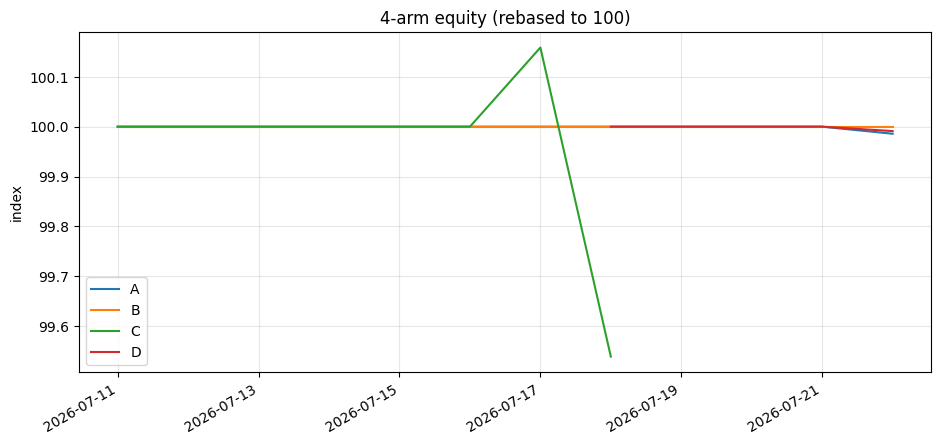

,A,B,C,D
2026-07-16,100.00000,100.0,100.00000,NaN
2026-07-17,100.00000,100.0,100.15878,NaN
2026-07-18,100.00000,100.0,99.53859,100.00000
2026-07-21,100.00000,100.0,NaN,100.00000
2026-07-22,99.98584,100.0,NaN,99.99114


In [2]:
curves = lr.equity_curves(DATA, rebased=True)
if not curves.empty and len(curves) > 1:
    ax = curves.plot(title="4-arm equity (rebased to 100)"); ax.set_ylabel("index"); ax.grid(alpha=.3); plt.show()
else:
    print(f"Only {len(curves)} day(s) - curve appears once >1 day accumulates.")
curves.tail()

In [3]:
m = lr.metrics_table(DATA)
print("History-dependent metrics (Sharpe etc.) populate once return_days >= 20.")
m[["strategy","days","return_days","current_equity","total_return_pct",
   "cagr_pct","sharpe","sortino","max_drawdown_pct","volatility_pct","enough_data"]]

History-dependent metrics (Sharpe etc.) populate once return_days >= 20.


,strategy,days,return_days,current_equity,total_return_pct,cagr_pct,sharpe,sortino,max_drawdown_pct,volatility_pct,enough_data
arm,,,,,,,,,,,
A,parallel ensemble (champion),8,7,99985.84,-0.01416,None,None,None,None,None,False
B,full sequential (herding contrast),8,7,100000.00,0.00000,None,None,None,None,None,False
C,equal-weight control (null model),6,5,99538.59,-0.46141,None,None,None,None,None,False
D,riskbudget calm_exposure (quant),3,2,99991.14,-0.00886,None,None,None,None,None,False


## 2 - Full QuantStats tearsheet per arm
The industry-standard deep financial analysis: full metrics set + plots
(rolling Sharpe, drawdown periods, monthly returns, distribution).
Inline via `qs.reports.full`; a standalone HTML tearsheet is also written to
`data/live/reports/{arm}.html` for the future published dashboard.

In [4]:
import quantstats as qs
MIN = 20
reports_dir = Path(DATA) / "live" / "reports"; reports_dir.mkdir(parents=True, exist_ok=True)
for arm in lr.ARMS:
    r = lr.load_returns(arm, DATA)
    print(f"\n{'='*70}\nArm {arm}: {lr.ARMS[arm]['label']}  ({len(r)} return days)\n{'='*70}")
    if len(r) >= MIN:
        try:
            qs.reports.full(r)  # metrics + plots inline
            out = reports_dir / f"{arm}.html"
            qs.reports.html(r, output=str(out), title=f"HiFi Arm {arm} - {lr.ARMS[arm]['label']}")
            print(f"saved tearsheet -> {out}")
        except Exception as e:
            print("tearsheet error (likely still too little data):", e)
    else:
        # early-days fallback: at least show the basic metric set QuantStats can compute
        try:
            qs.reports.metrics(r, mode="basic", display=True)
        except Exception:
            print(f"<{MIN} return days - full tearsheet pending.")


Arm A: parallel ensemble (champion)  (7 return days)

Parameter       Value
--------------  -------
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                     Strategy
-------------------  ----------
Start Period         2026-07-14
End Period           2026-07-22
Risk-Free Rate       0.0%
Time in Market       15.0%

Cumulative Return    -0.01%
CAGR﹪               -0.51%

Sharpe               -6.0
Prob. Sharpe Ratio   2.28%
Sortino              -6.0
Sortino/√2           -4.24
Omega                0.0

Max Drawdown         -0.01%
Max DD Date          2026-07-22
Max DD Period Start  2026-07-22
Max DD Period End    2026-07-22
Longest DD Days      1

Gain/Pain Ratio      -1.0
Gain/Pain (1M)       -1.0

Payoff Ratio         -
Profit Factor        0.0
Common Sense Ratio   0.0
CPC Index            -
Tail Ratio           0.0
Outlier Win Ratio    -
Outlier Loss Ratio   0.94

MTD                  -0.01%
3M                   -0.01%
6M                  

/Users/alberto/Documents/projects/HiFi/.venv/lib/python3.12/site-packages/quantstats/stats.py:546: UserWarning: No non-zero returns found for win rate calculation, returning 0.0
  warn("No non-zero returns found for win rate calculation, returning 0.0")
/Users/alberto/Documents/projects/HiFi/.venv/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2334: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/Users/alberto/Documents/projects/HiFi/.venv/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2335: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


## 3 - Decision-science layer
How the strategies *decide*, not just what they return - the novel contribution.

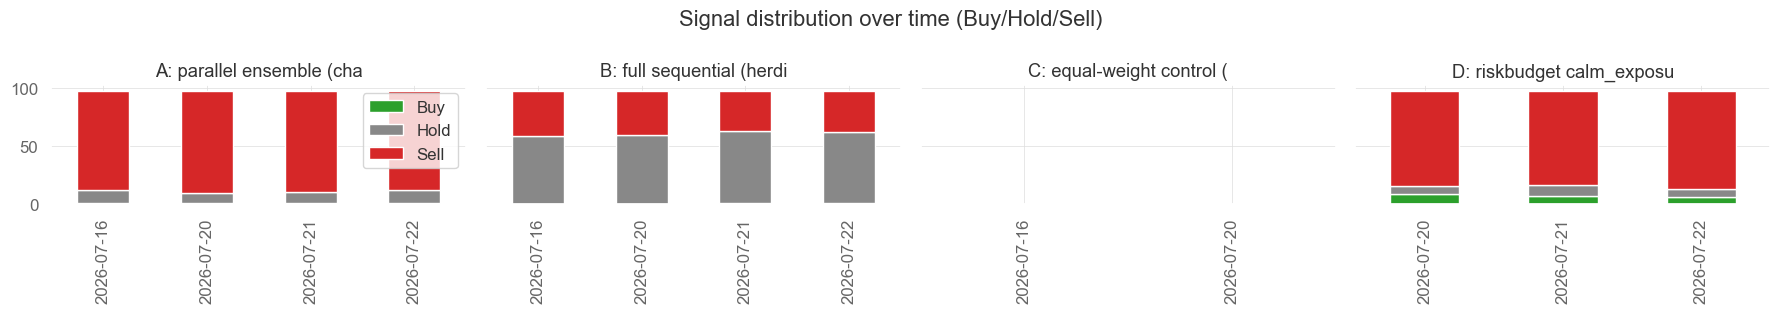

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.2), sharey=True)
for ax, arm in zip(axes, lr.ARMS):
    sd = lr.signal_distribution(arm, DATA)
    if not sd.empty:
        sd.set_index("decision_date")[["Buy","Hold","Sell"]].plot(
            kind="bar", stacked=True, ax=ax, legend=(arm=="A"),
            color={"Buy":"#2ca02c","Hold":"#888888","Sell":"#d62728"})
    ax.set_title(f"{arm}: {lr.ARMS[arm]['label'][:22]}"); ax.set_xlabel("")
plt.suptitle("Signal distribution over time (Buy/Hold/Sell)"); plt.tight_layout(); plt.show()

### 3b - Herding vs diversity (LLM arms)
Page's theorem, live: **unanimity** = fraction of tickers where all agents agreed
(high = herding); **mean_entropy** = cross-agent disagreement (high = diverse).
Phase 15: parallel (A) diverse / low-herding, full (B) higher-herding.

In [6]:
for arm in ["A","B"]:
    h = lr.herding_series(arm, DATA)
    if h.empty:
        print(f"Arm {arm}: no ensemble sidecars yet."); continue
    print(f"=== Arm {arm} ({lr.ARMS[arm]['label']}) ===")
    print(h.to_string(index=False))

=== Arm A (parallel ensemble (champion)) ===
decision_date  n_tickers  unanimity  mean_entropy
   2026-07-16         98        0.0      0.936457
   2026-07-20         98        0.0      0.925292
   2026-07-21         98        0.0      0.932915
   2026-07-22         98        0.0      0.931915
=== Arm B (full sequential (herding contrast)) ===
decision_date  n_tickers  unanimity  mean_entropy
   2026-07-16         98   0.153061      0.759509
   2026-07-20         98   0.163265      0.745520
   2026-07-21         98   0.183673      0.698674
   2026-07-22         98   0.183673      0.711919


### 3c - Live Information Coefficient (pending)
IC (rank corr of signal vs 60-day forward return) needs forward-return labels
(Phase 16 E3), available once >=60 trading days elapse. Placeholder for structure.

In [7]:
print("Live IC:", lr.experiment_status(DATA)["ic_status"])

Live IC: pending — needs 60-day forward labels (Phase 16 E3)


## 4 - AI-operations layer (LangFuse)
The compute/cost/latency/reliability of the AI itself - per model, from LangFuse
traces. Distinct from 3 (what agents decided); this is *how* the LLMs ran.
Empty if LangFuse is unreachable (telemetry is a convenience layer; the durable
decision record lives in the sidecars).

In [8]:
from hifi.analytics import langfuse_report as lf
gens = lf.fetch_generations(max_items=20000)
summary = lf.llm_ops_summary(gens)
print("LLM-ops summary:", summary)
usage = lf.model_usage_table(gens)
usage

LLM-ops summary: {'n_calls': 3802, 'total_tokens': 6725612, 'n_models': 4, 'mean_latency_s': 16.06, 'error_rate': 0.0, 'first': '2026-07-14 04:26:09.660000+00:00', 'last': '2026-07-23 04:36:10.521000+00:00'}


,n_calls,total_tokens,mean_prompt_tokens,mean_completion_tokens,mean_latency_s,p95_latency_s,error_rate
model,,,,,,,
llama-3.3-70b-instruct,1055,3018499,2709.0,152.0,31.08,39.63,0.0
/Users/alberto/.lmstudio/models/lmstudio-community/Qwen2.5-Coder-32B-Instruct-MLX-8bit,954,1280827,1252.0,91.0,9.31,12.68,0.0
mistral-small-3.2-24b-instruct-2506-mlx,904,1052704,1021.0,144.0,4.34,6.89,0.0
deepseek-r1-distill-qwen-32b,888,1373582,1049.0,498.0,17.42,23.62,0.0
NaN,1,0,0.0,0.0,0.00,0.00,0.0


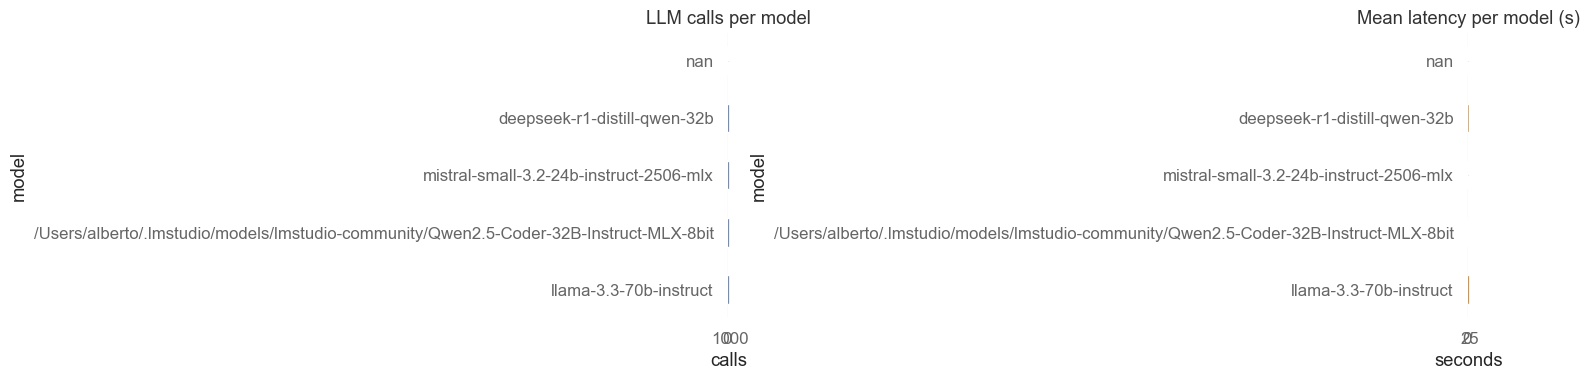

In [9]:
if not gens.empty:
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))
    u = lf.model_usage_table(gens)
    u["n_calls"].plot(kind="barh", ax=ax[0], title="LLM calls per model"); ax[0].set_xlabel("calls")
    u["mean_latency_s"].plot(kind="barh", ax=ax[1], color="#d97706",
                             title="Mean latency per model (s)"); ax[1].set_xlabel("seconds")
    plt.tight_layout(); plt.show()
else:
    print("No LangFuse telemetry available.")